# Exploratory Data Analysis

<div style="text-align: justify">

The following notebook is dedicated to exploratory data analysis for the <b>Tau Anomaly Detection</b> analysis. EDA is performed on the rectangularized MC DataFrame produced by the feature engineering pipeline, and covers data quality, sample composition, feature correlations, and feature distributions.

</div>

## Analysis Steps

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis configuration |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Labels | `eda.utils.get_sample_labels` | Derive sample labels from eventOrigin |
| Missing | `eda.checks.summarize_missing` | Check for remaining NaN values |
| Ranges | `eda.checks.summarize_feature_ranges` | Per-sample min, max, mean and std per feature |
| Balance | `eda.plots.plot_sample_balance` | Unweighted and weighted event counts per sample |
| Correlation | `eda.plots.plot_correlation_matrix` | Pearson feature correlation heatmap |
| Distributions | `eda.plots.plot_feature_distributions` | Per-sample normalized feature histograms |

The same analysis is available as a CLI via `uv run python run.py stage=eda`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)

Data Visualization:
* [Matplotlib](https://matplotlib.org/)
* [Seaborn](https://seaborn.pydata.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration. All analysis parameters (run, region, channel, samples, features) are defined in `configs/` and can be overridden here.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

Resolving the input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
plots_dir = path / output_paths["plots_dir"] / "eda"
plots_dir.mkdir(parents=True, exist_ok=True)

## Deserialization

Loading the MC DataFrame produced by the feature engineering pipeline.

In [6]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")

The `sample_type` column is created by the feature engineering pipeline: background samples keep their process name, all signal mass points are grouped as `"signal"`. This column is used for sample balance plots and feature distributions.

In [7]:
assert "sample_type" in df_mc.columns, "sample_type missing — re-run feature engineering"

df_mc["sample_type"].value_counts()

sample_type
ztautau      2314192
signal       1986073
diboson      1846720
wtaunu       1716897
topquarks    1139269
other         824018
Name: count, dtype: int64

## Sample Labels

Deriving sample labels from `eventOrigin` for use in plots and tables.

In [8]:
from src.eda.utils import get_sample_labels

sample_labels = get_sample_labels(df_mc)
sample_labels

['GG_1000_700',
 'GG_1000_800_J85_1tau',
 'GG_1000_850_J85_1tau',
 'GG_1000_900_J85_1tau',
 'GG_1000_925_J85_1tau',
 'GG_1000_950_J85_1tau',
 'GG_1000_970_J85_1tau',
 'GG_1050_1020_J85_1tau',
 'GG_1100_100',
 'GG_1100_1000_J85_1tau',
 'GG_1100_1025_J85_1tau',
 'GG_1100_1050_J85_1tau',
 'GG_1100_200',
 'GG_1100_300',
 'GG_1100_400',
 'GG_1100_500',
 'GG_1100_600',
 'GG_1100_700',
 'GG_1100_800',
 'GG_1100_900_J85_1tau',
 'GG_1100_950_J85_1tau',
 'GG_1200_1000_J85_1tau',
 'GG_1200_1050_J85_1tau',
 'GG_1200_1100_J85_1tau',
 'GG_1200_1125_J85_1tau',
 'GG_1200_1150_J85_1tau',
 'GG_1200_700',
 'GG_1200_800',
 'GG_1200_900',
 'GG_1300_100',
 'GG_1300_1000',
 'GG_1300_1100_J85_1tau',
 'GG_1300_1150_J85_1tau',
 'GG_1300_1200_J85_1tau',
 'GG_1300_1225_J85_1tau',
 'GG_1300_1250_J85_1tau',
 'GG_1300_200',
 'GG_1300_300',
 'GG_1300_400',
 'GG_1300_500',
 'GG_1300_600',
 'GG_1300_700',
 'GG_1300_800',
 'GG_1300_900',
 'GG_1400_1000',
 'GG_1400_1100',
 'GG_1400_1200_J85_1tau',
 'GG_1400_1250_J85_1tau

In [9]:
df_mc

,nVtx,LeptonVeto,jet_n,jet_n_btag,sumMTJet,sumMTTauJet,met,met_phi,METSig,meff,...,jet_jvt_2,jet_delPhiMet_0,jet_delPhiMet_1,jet_delPhiMet_2,jet_width_0,jet_width_1,jet_width_2,eventOrigin,tau_n,sample_type
entry,,,,,,,,,,,,,,,,,,,,,
0,18,True,4,2,993838.375,1.035837e+06,2.512104e+05,-1.727673,12.867966,6.483069e+05,...,0.994129,2.684723,2.335376,2.842570,0.056821,0.076281,0.042212,topquarks,1,topquarks
1,11,True,4,2,1129536.375,1.160733e+06,2.425238e+05,1.655179,12.812569,7.935587e+05,...,0.994528,2.592552,1.729147,3.038795,0.056552,0.063856,0.196646,topquarks,1,topquarks
2,17,True,7,2,1715605.625,1.730615e+06,2.086409e+05,-0.276374,8.978572,1.320639e+06,...,0.995531,2.131062,2.642069,0.417061,0.051609,0.075280,0.168994,topquarks,1,topquarks
3,10,True,5,2,1062983.750,1.126216e+06,2.068697e+05,2.280369,11.774617,6.442722e+05,...,0.990000,2.995725,1.983203,1.282939,0.081907,0.150282,0.050103,topquarks,1,topquarks
4,27,True,4,0,896357.375,9.441957e+05,2.095323e+05,-3.135049,11.435131,5.574934e+05,...,0.983820,3.061255,2.934011,3.036008,0.090903,0.092126,0.113758,topquarks,1,topquarks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9827164,18,True,2,0,635148.375,7.503884e+05,2.780631e+05,-1.159799,13.717712,6.100386e+05,...,0.000000,3.130677,0.911731,0.000000,0.025179,0.128983,0.000000,SS_900_870_J85_1tau,1,signal
9827165,22,True,6,0,3874650.250,3.925604e+06,1.003722e+06,-0.666699,24.657297,2.145574e+06,...,0.997932,2.985127,3.046724,2.751268,0.089573,0.077406,0.175705,SS_900_870_J85_1tau,1,signal
9827166,28,True,6,0,2673043.000,2.775120e+06,6.822745e+05,-1.799938,21.382816,1.981064e+06,...,0.989980,2.851266,0.840484,2.365701,0.022959,0.069122,0.140405,SS_900_870_J85_1tau,1,signal


## Data Quality

### Missing Values

Checking for remaining NaN values after padding fill. An empty table indicates a clean DataFrame.

In [10]:
from src.eda.checks import summarize_missing

summarize_missing(df_mc)

,missing,fraction


### Feature Ranges

Inspecting per-sample min, max, mean and std for all numeric features.

In [11]:
from src.eda.checks import summarize_feature_ranges

summarize_feature_ranges(df_mc)

nVtx                          jet_n                \
                      min max       mean       std   min max      mean   
eventOrigin                                                              
GG_1000_700             1  53  20.187023  7.172836     2  14  5.992684   
GG_1000_800_J85_1tau    1  53  20.289059  7.171421     2  14  5.916794   
GG_1000_850_J85_1tau    1  68  20.208971  7.395449     2  13  5.518470   
GG_1000_900_J85_1tau    2  60  20.146474  7.356531     2  11  4.899819   
GG_1000_925_J85_1tau    2  55  20.032119  7.378615     2  11  4.550957   
...                   ...  ..        ...       ...   ...  ..       ...   
diboson                 1  86  20.238849  7.298126     2  16  3.766496   
other                   1  84  21.011495  7.476858     2  17  3.801508   
topquarks               1  82  20.414470  7.324052     2  19  5.077731   
wtaunu                  1  82  19.488759  7.288239     2  20  3.763561   
ztautau                 1  85  20.164587  7.316183     2  20  3.947259   

                               jet_n_btag      ... jet_width_1            \
                           std        min max  ...        mean       std   
eventOrigin                                    ...                         
GG_1000_700           1.763528          0   4  ...    0.089581  0.043444   
GG_1000_800_J85_1tau  1.757201          0   4  ...    0.099545  0.044706   
GG_1000_850_J85_1tau  1.735796          0   5  ...    0.103669  0.044440   
GG_1000_900_J85_1tau  1.673758          0   4  ...    0.107746  0.046133   
GG_1000_925_J85_1tau  1.675193          0   3  ...    0.110690  0.047301   
...                        ...        ...  ..  ...         ...       ...   
diboson               1.581588          0   6  ...    0.093189  0.047104   
other                 1.732320          0   5  ...    0.106430  0.050297   
topquarks             1.824186          0   8  ...    0.091910  0.043547   
wtaunu                1.706395          0   6  ...    0.096742  0.049992   
ztautau               1.756261          0   6  ...    0.095808  0.050094   

                     jet_width_2                               tau_n           \
                             min       max      mean       std   min max mean   
eventOrigin                                                                     
GG_1000_700                  0.0  0.245178  0.095166  0.043872     1   1  1.0   
GG_1000_800_J85_1tau         0.0  0.267856  0.104479  0.044857     1   1  1.0   
GG_1000_850_J85_1tau         0.0  0.261374  0.111363  0.047231     1   1  1.0   
GG_1000_900_J85_1tau         0.0  0.278236  0.115463  0.052372     1   1  1.0   
GG_1000_925_J85_1tau         0.0  0.255887  0.114195  0.058142     1   1  1.0   
...                          ...       ...       ...       ...   ...  ..  ...   
diboson                      0.0  0.291606  0.087731  0.065807     1   1  1.0   
other                        0.0  0.285859  0.091134  0.069697     1   1  1.0   
topquarks                    0.0  0.292606  0.102928  0.051592     1   1  1.0   
wtaunu                       0.0  0.288881  0.086782  0.067938     1   1  1.0   
ztautau                      0.0  0.289891  0.087756  0.066191     1   1  1.0   

                           
                      std  
eventOrigin                
GG_1000_700           0.0  
GG_1000_800_J85_1tau  0.0  
GG_1000_850_J85_1tau  0.0  
GG_1000_900_J85_1tau  0.0  
GG_1000_925_J85_1tau  0.0  
...                   ...  
diboson               0.0  
other                 0.0  
topquarks             0.0  
wtaunu                0.0  
ztautau               0.0  

[316 rows x 216 columns]

## Sample Composition

Plotting unweighted and weighted event counts per sample type. The weighted panel uses physics event weights to show the expected event yield.

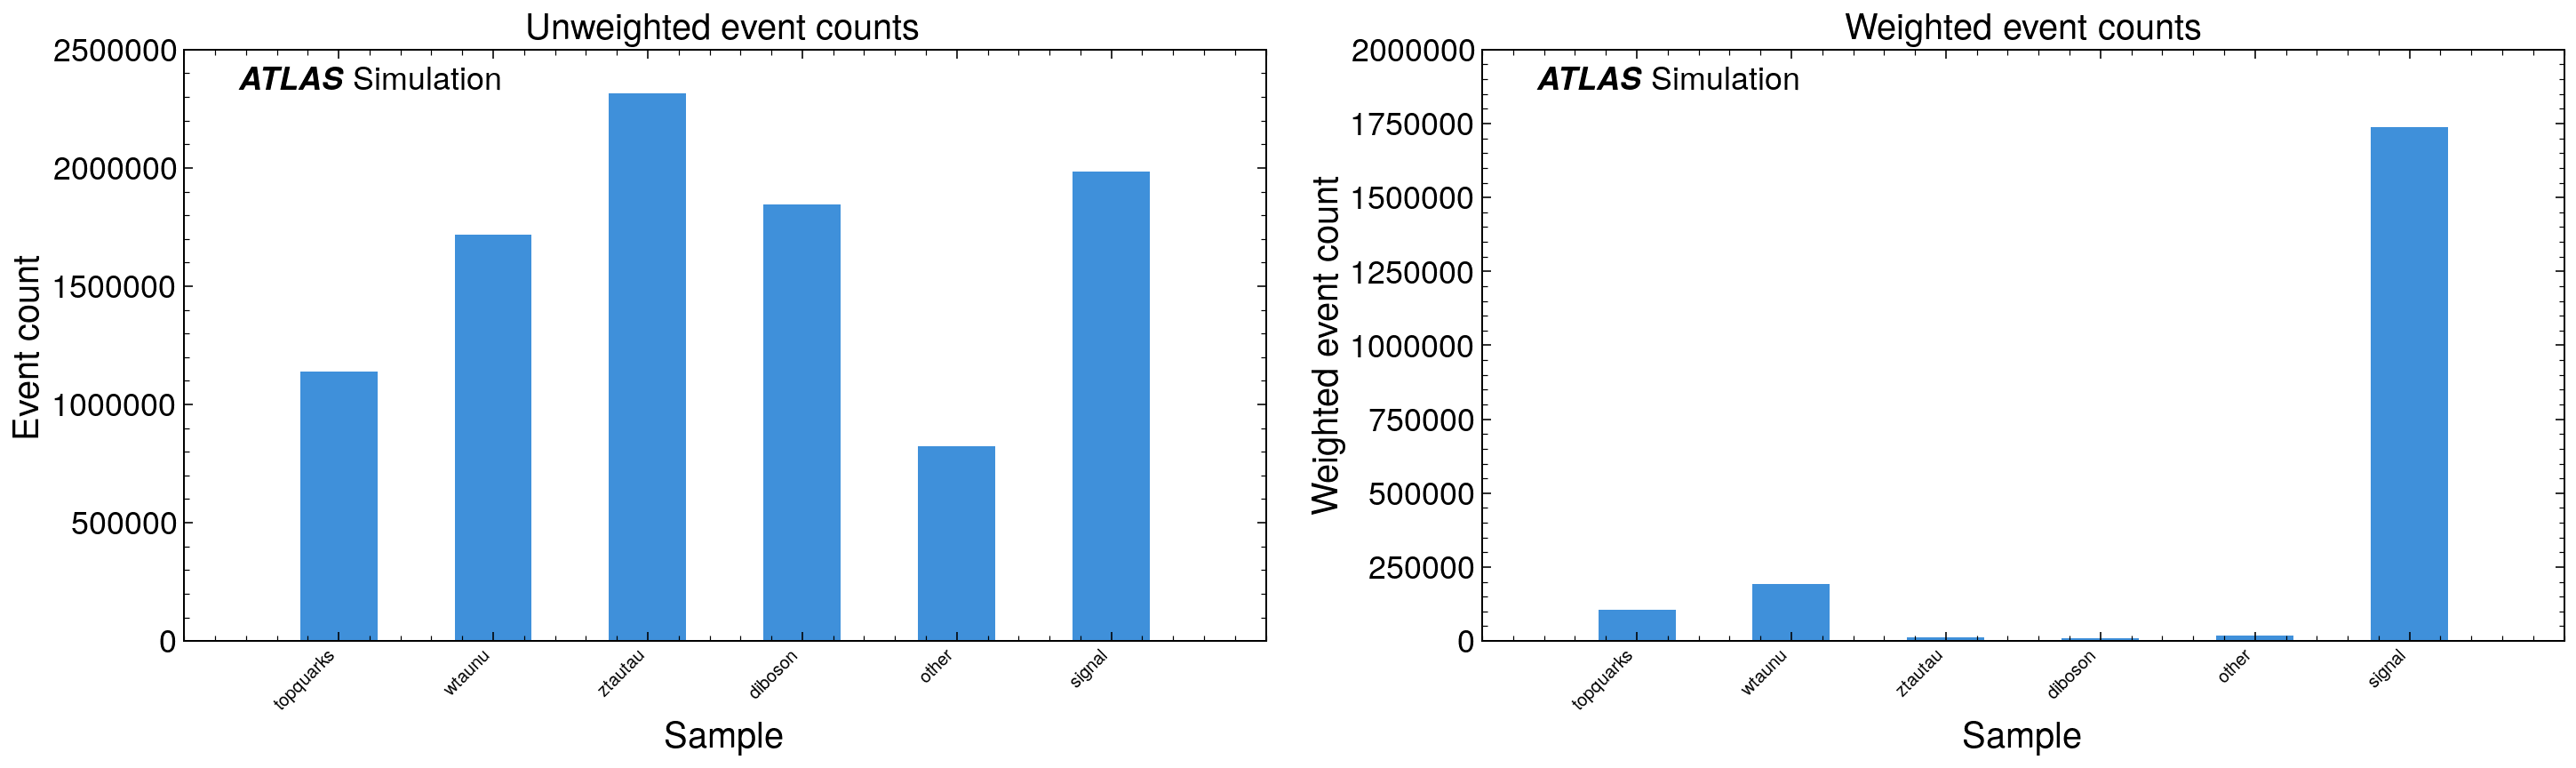

In [12]:
from src.eda.plots import plot_sample_balance
from src.visualization.plots import save_figure

fig = plot_sample_balance(df_mc)
save_figure(fig, plots_dir / "sample_balance.png")
fig.show()

## Correlations

Plotting the Pearson correlation matrix for all training features. Highly correlated feature pairs (|r| > 0.9) are candidates for removal to reduce redundancy. Annotations are shown only for matrices with 30 or fewer features.

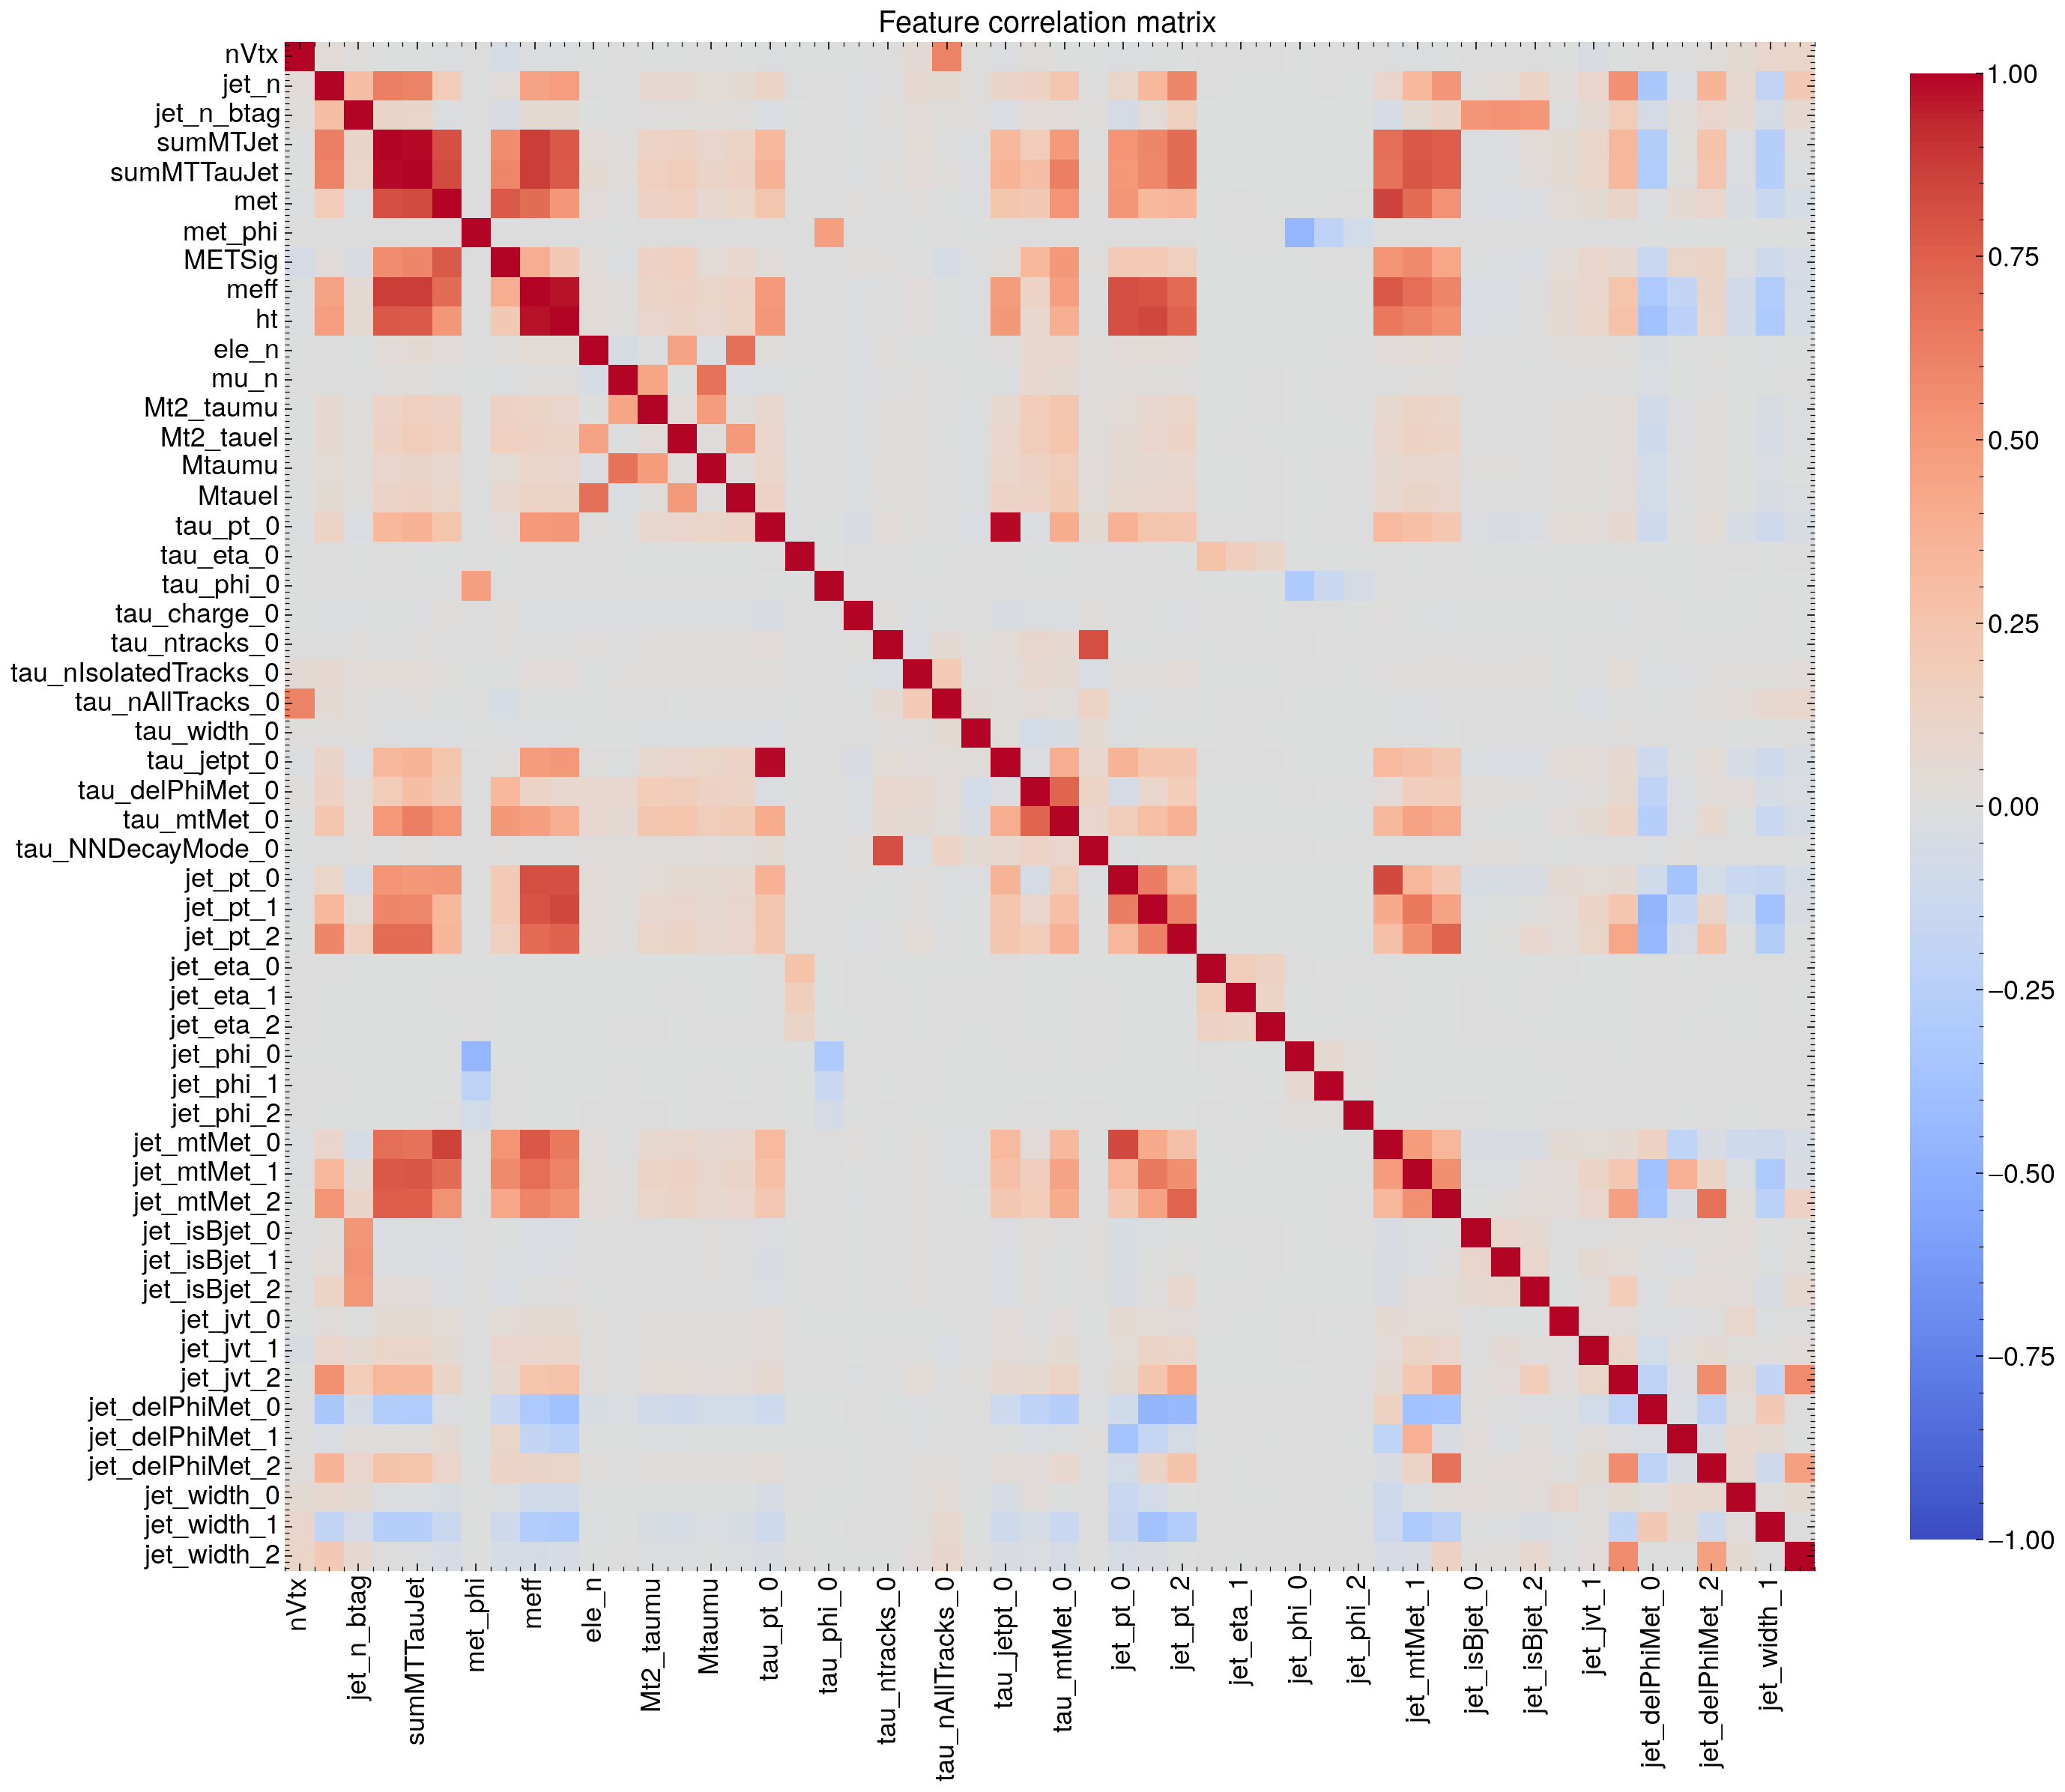

In [13]:
from src.eda.plots import plot_correlation_matrix
from src.visualization.plots import save_figure

fig = plot_correlation_matrix(df_mc)
save_figure(fig, plots_dir / "correlation_matrix.png")
fig.show()

## Feature Distributions

Plotting per-sample normalized histograms for a selection of features. Modify `features` to inspect any subset of columns.

In [14]:
from src.eda.plots import plot_feature_distributions
from src.visualization.plots import save_figure

training_cols = [
    c for c in df_mc.select_dtypes(include="number").columns
    if c not in {"tau_n", "weight"}
]
features = training_cols[::]

fig = plot_feature_distributions(df_mc, features=features, group_col="sample_type")
save_figure(fig, plots_dir / "feature_distributions.png")
fig.show()